# This minor project for VIOS_DA_internship_Aug,2026 program by Edunet fundation in collaboraion with VIOS through AICTE

**This Analysis project where we analyze car market trends with Car_Dekho dataset**.



---





*The analysis happens here are against different questions. The questions are in following:*

1. From which manufacturing year to which manufacturing year vehicles are present in this data ?

2. What is the lowest price to which a vehicle is sold?

3. What is the highest price to which a vehicle is sold?

4. How many records are there in this data ?

5. Are there any missing records in this data?

6. How many different vehicles are present in this data ?

7. Which is the most sold vehicle in this data?

8. Does the database include any CNG vehicle? If yes how many of them are there?

9. How many vehicles here are for sell from Individuals directly?

10. Does this database contain auto transmission vehicles? If yes how many of them are there?

11. How many single person owned vehicles are there in this database?

12. Which is the most and least cost depreciated vehicle in data ?

13. Which brands of vehicles are less affected by cost depreciation?

14. Are there any factors which you feel affect the cost depreciation?

15. In general selling price is affected by age of vehicle and distance driven by vehicle, is it observable from data ?

16. Can we get idea about newest vehicles i.e. after 2014 manufactured?

17. Can we find out data of only two wheelers from this data ?

18. Which is the oldest bike sold here?

19. Which is the newest bike sold here?

20. Which is the most sold bike here?

21. Do you find any deal in two wheelers which exceeded the general expectation? Can you find reason for it?

22. Can we find out data of only cars from this data ?

23. Which is the oldest car sold here?

24. Which is the newest car sold here?

25. Do you find any deal in cars which exceeded the general expectation ? Can you find reason for it?

---



Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
df = pd.read_csv('/content/Car Market Trends Analysis with Car Dekho Data.csv')

# Feature Engineering
df['Vehicle_Age'] = 2018 - df['Year']  # Dataset reference max year is 2018
df['Cost_Depreciation'] = df['Present_Price'] - df['Selling_Price']
df['Depreciation_Pct'] = (df['Cost_Depreciation'] / df['Present_Price']) * 100
df['Retention_Pct'] = (df['Selling_Price'] / df['Present_Price']) * 100

# Segregate Two-Wheelers vs Cars
two_wheeler_keywords = ['Activa', 'Bajaj', 'Hero', 'Honda CB', 'Honda CBR', 'Honda Dream',
                        'Honda Karizma', 'Honda Activa', 'Honda Shine', 'Hyosung', 'KTM',
                        'Mojo', 'Royal Enfield', 'Suzuki Access', 'TVS', 'UM', 'Yamaha']

df['Vehicle_Type'] = df['Car_Name'].apply(
    lambda x: 'Two-Wheeler' if any(kw.lower() in x.lower() for kw in two_wheeler_keywords) else 'Car'
)

# Extract Brand
brand_mapping = {
    'ritz': 'Maruti', 'sx4': 'Maruti', 'ciaz': 'Maruti', 'wagon r': 'Maruti', 'swift': 'Maruti',
    'vitara brezza': 'Maruti', 's cross': 'Maruti', 'alto 800': 'Maruti', 'ertiga': 'Maruti',
    'dzire': 'Maruti', 'alto k10': 'Maruti', 'ignis': 'Maruti', 'baleno': 'Maruti', 'omni': 'Maruti', '800': 'Maruti',
    'fortuner': 'Toyota', 'innova': 'Toyota', 'corolla altis': 'Toyota', 'etios cross': 'Toyota',
    'etios g': 'Toyota', 'etios liva': 'Toyota', 'corolla': 'Toyota', 'etios gd': 'Toyota', 'camry': 'Toyota', 'land cruiser': 'Toyota',
    'i20': 'Hyundai', 'grand i10': 'Hyundai', 'i10': 'Hyundai', 'eon': 'Hyundai', 'xcent': 'Hyundai',
    'elantra': 'Hyundai', 'creta': 'Hyundai', 'verna': 'Hyundai',
    'city': 'Honda', 'brio': 'Honda', 'amaze': 'Honda', 'jazz': 'Honda'
}

def get_brand(name):
    name_clean = name.strip()
    if name_clean in brand_mapping:
        return brand_mapping[name_clean]
    return name_clean.split()[0].capitalize()

df['Brand'] = df['Car_Name'].apply(get_brand)

print("Dataset Loaded Successfully. Shape:", df.shape)
df.head()

Dataset Loaded Successfully. Shape: (301, 15)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age,Cost_Depreciation,Depreciation_Pct,Retention_Pct,Vehicle_Type,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4,2.24,40.071556,59.928444,Car,Maruti
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5,4.79,50.209644,49.790356,Car,Maruti
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1,2.60,26.395939,73.604061,Car,Maruti
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7,1.30,31.325301,68.674699,Car,Maruti
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4,2.27,33.042213,66.957787,Car,Maruti


**Basic Dataset Metrics**

Answers Questions: 1, 2, 3, 4, 5, 6, 7

In [2]:
print("="*60)
print("BASIC DATASET METRICS")
print("="*60)

# Q1: Manufacturing Year Range
min_year = df['Year'].min()
max_year = df['Year'].max()
print(f"Q1: Manufacturing Year Range      : {min_year} to {max_year}")

# Q2: Lowest Selling Price
min_price = df['Selling_Price'].min()
print(f"Q2: Lowest Selling Price         : ₹{min_price:.2f} Lakhs ({min_price * 100000:.0f} INR)")

# Q3: Highest Selling Price
max_price = df['Selling_Price'].max()
print(f"Q3: Highest Selling Price        : ₹{max_price:.2f} Lakhs ({max_price * 100000:.0f} INR)")

# Q4: Total Records
total_records = len(df)
print(f"Q4: Total Records in Dataset     : {total_records}")

# Q5: Missing Records
missing_count = df.isnull().sum().sum()
print(f"Q5: Total Missing Values         : {missing_count}")

# Q6: Different Vehicles
unique_vehicles = df['Car_Name'].nunique()
print(f"Q6: Unique Vehicle Models        : {unique_vehicles}")

# Q7: Most Sold Vehicle
most_sold_vehicle = df['Car_Name'].value_counts().idxmax()
most_sold_count = df['Car_Name'].value_counts().max()
print(f"Q7: Most Sold Vehicle            : {most_sold_vehicle} ({most_sold_count} sales)")
print("="*60)

BASIC DATASET METRICS
Q1: Manufacturing Year Range      : 2003 to 2018
Q2: Lowest Selling Price         : ₹0.10 Lakhs (10000 INR)
Q3: Highest Selling Price        : ₹35.00 Lakhs (3500000 INR)
Q4: Total Records in Dataset     : 301
Q5: Total Missing Values         : 0
Q6: Unique Vehicle Models        : 98
Q7: Most Sold Vehicle            : city (26 sales)


Answers Questions: 8, 9, 10, 11

VEHICLE ATTRIBUTES BREAKDOWN
Q8:  CNG Vehicles Count          : 2
Q9:  Direct Individual Sellers   : 106
Q10: Automatic Transmission      : 40
Q11: Single-Owned Vehicles       : 290


/tmp/ipykernel_7404/1631059387.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fuel_Type', ax=axes[0, 0], palette='Blues_d')
/tmp/ipykernel_7404/1631059387.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Seller_Type', ax=axes[0, 1], palette='Greens_d')
/tmp/ipykernel_7404/1631059387.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Transmission', ax=axes[1, 0], palette='Oranges_d')
/tmp/ipykernel_7404/1631059387.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

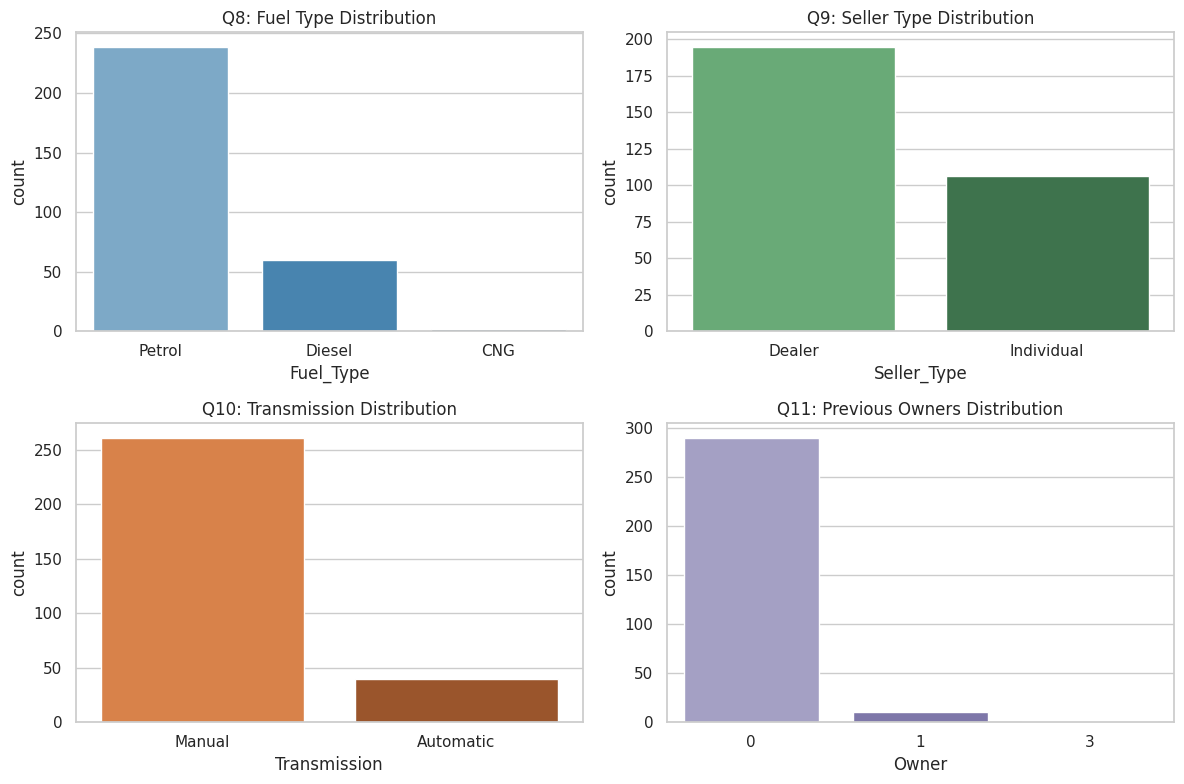

In [3]:
# Q8: CNG Vehicles
cng_count = (df['Fuel_Type'] == 'CNG').sum()

# Q9: Individual Sellers
individual_count = (df['Seller_Type'] == 'Individual').sum()

# Q10: Automatic Transmission
auto_count = (df['Transmission'] == 'Automatic').sum()

# Q11: Single Person Owned (Owner == 0 indicates first/single owner before resale)
single_owner_count = (df['Owner'] == 0).sum()

print("="*60)
print("VEHICLE ATTRIBUTES BREAKDOWN")
print("="*60)
print(f"Q8:  CNG Vehicles Count          : {cng_count}")
print(f"Q9:  Direct Individual Sellers   : {individual_count}")
print(f"Q10: Automatic Transmission      : {auto_count}")
print(f"Q11: Single-Owned Vehicles       : {single_owner_count}")
print("="*60)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.countplot(data=df, x='Fuel_Type', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Q8: Fuel Type Distribution')

sns.countplot(data=df, x='Seller_Type', ax=axes[0, 1], palette='Greens_d')
axes[0, 1].set_title('Q9: Seller Type Distribution')

sns.countplot(data=df, x='Transmission', ax=axes[1, 0], palette='Oranges_d')
axes[1, 0].set_title('Q10: Transmission Distribution')

sns.countplot(data=df, x='Owner', ax=axes[1, 1], palette='Purples_d')
axes[1, 1].set_title('Q11: Previous Owners Distribution')
plt.tight_layout()
plt.show()

Answers Questions: 12, 13, 14, 15

DEPRECIATION ANALYSIS
Q12: Highest Absolute Depreciation: land cruiser (Lost ₹57.60 Lakhs)
     Lowest Absolute Depreciation : Honda Activa 4G (Lost ₹0.03 Lakhs)
     Lowest Percentage Deprec.    : corolla altis (Lost only 1.07%)

Q13: Average Cost Depreciation by Brand (Min 5 vehicles in data):
Brand
Royal      26.140059
Hyundai    29.145760
Yamaha     30.649037
Tvs        33.890343
Honda      35.335132
Maruti     36.216918
Hero       40.883727
Bajaj      41.380263
Toyota     47.523816


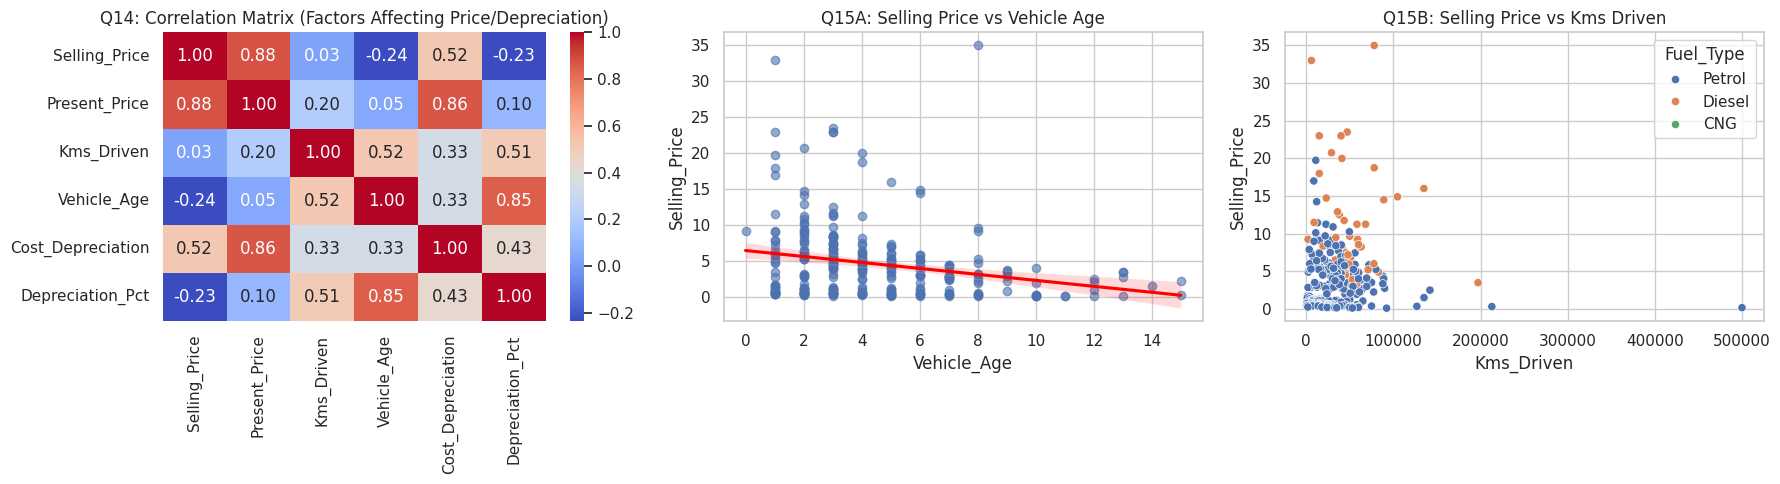

In [4]:
# Q12: Most & Least Depreciated Vehicles
most_dep_abs = df.loc[df['Cost_Depreciation'].idxmax()]
least_dep_abs = df.loc[df['Cost_Depreciation'].idxmin()]
least_dep_pct = df.loc[df['Depreciation_Pct'].idxmin()]

print("="*60)
print("DEPRECIATION ANALYSIS")
print("="*60)
print(f"Q12: Highest Absolute Depreciation: {most_dep_abs['Car_Name']} (Lost ₹{most_dep_abs['Cost_Depreciation']:.2f} Lakhs)")
print(f"     Lowest Absolute Depreciation : {least_dep_abs['Car_Name']} (Lost ₹{least_dep_abs['Cost_Depreciation']:.2f} Lakhs)")
print(f"     Lowest Percentage Deprec.    : {least_dep_pct['Car_Name']} (Lost only {least_dep_pct['Depreciation_Pct']:.2f}%)")

# Q13: Brand Resilience
brand_dep = df.groupby('Brand').filter(lambda x: len(x) >= 5).groupby('Brand')['Depreciation_Pct'].mean().sort_values()
print("\nQ13: Average Cost Depreciation by Brand (Min 5 vehicles in data):")
print(brand_dep.to_string())

# Q14 & Q15: Correlations & Factors
numeric_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Vehicle_Age', 'Cost_Depreciation', 'Depreciation_Pct']
corr_matrix = df[numeric_cols].corr()

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Q14: Correlation Matrix (Factors Affecting Price/Depreciation)')

# Price vs Vehicle Age
sns.regplot(data=df, x='Vehicle_Age', y='Selling_Price', ax=axes[1], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[1].set_title('Q15A: Selling Price vs Vehicle Age')

# Price vs Kms Driven
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price', hue='Fuel_Type', ax=axes[2])
axes[2].set_title('Q15B: Selling Price vs Kms Driven')

plt.tight_layout()
plt.show()

Answers Questions: 16

Q16: VEHICLES MANUFACTURED AFTER 2014 (> 2014)
Count of vehicles manufactured after 2014 : 147 (48.8% of dataset)
Average Selling Price                     : ₹5.77 Lakhs
Average Present Price                     : ₹7.36 Lakhs
Average Value Retention                   : 78.30%
Top 5 Most Prevalent Post-2014 Models:
 Car_Name
city         16
ciaz          8
grand i10     7
brio          7
jazz          6
Name: count, dtype: int64


/tmp/ipykernel_7404/4263734795.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=new_vehicles, x='Year', palette='viridis')


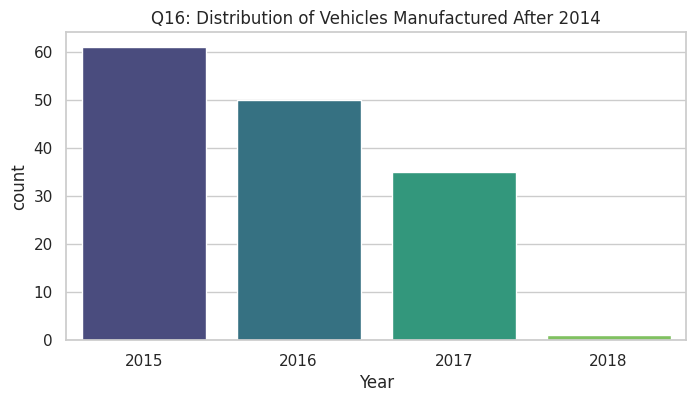

In [5]:
# Q16: Vehicles manufactured after 2014 (2015 to 2018)
new_vehicles = df[df['Year'] > 2014]

print("="*60)
print("Q16: VEHICLES MANUFACTURED AFTER 2014 (> 2014)")
print("="*60)
print(f"Count of vehicles manufactured after 2014 : {len(new_vehicles)} ({len(new_vehicles)/len(df)*100:.1f}% of dataset)")
print(f"Average Selling Price                     : ₹{new_vehicles['Selling_Price'].mean():.2f} Lakhs")
print(f"Average Present Price                     : ₹{new_vehicles['Present_Price'].mean():.2f} Lakhs")
print(f"Average Value Retention                   : {new_vehicles['Retention_Pct'].mean():.2f}%")
print("Top 5 Most Prevalent Post-2014 Models:\n", new_vehicles['Car_Name'].value_counts().head(5))

# Plot Post-2014 Distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=new_vehicles, x='Year', palette='viridis')
plt.title('Q16: Distribution of Vehicles Manufactured After 2014')
plt.show()

Answers Questions: 17, 18, 19, 20, 21

TWO-WHEELERS ANALYSIS
Q17: Total Two-Wheelers in Data  : 101
Q18: Oldest Bike Sold            : Hero Super Splendor (2005) - ₹0.2 Lakhs
Q19: Newest Bike Sold            : UM Renegade Mojave (2017) - ₹1.7 Lakhs
Q20: Most Sold Bike              : Royal Enfield Classic 350 (7 units)
Q21: Highest Priced Bike Deal    : Royal Enfield Thunder 500 (2016) sold for ₹1.75 Lakhs (Driven only 3000 km)
     Highest Value Retention     : Bajaj Avenger 220 (2017) retained 94.74% of original price


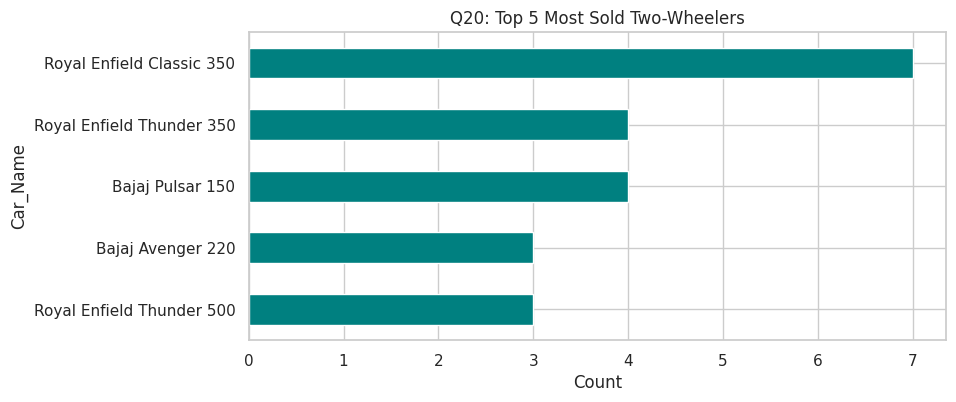

In [6]:
# Q17: Filter Two-Wheelers
bikes_df = df[df['Vehicle_Type'] == 'Two-Wheeler']

# Q18: Oldest Bike
oldest_bike = bikes_df.loc[bikes_df['Year'].idxmin()]

# Q19: Newest Bike
newest_bike = bikes_df.loc[bikes_df['Year'].idxmax()]

# Q20: Most Sold Bike
most_sold_bike = bikes_df['Car_Name'].value_counts().idxmax()
most_sold_bike_count = bikes_df['Car_Name'].value_counts().max()

# Q21: Standout / Exceptional Bike Deal
top_bike_deal = bikes_df.sort_values(by='Selling_Price', ascending=False).iloc[0]
best_retention_bike = bikes_df.sort_values(by='Retention_Pct', ascending=False).iloc[0]

print("="*60)
print("TWO-WHEELERS ANALYSIS")
print("="*60)
print(f"Q17: Total Two-Wheelers in Data  : {len(bikes_df)}")
print(f"Q18: Oldest Bike Sold            : {oldest_bike['Car_Name']} ({oldest_bike['Year']}) - ₹{oldest_bike['Selling_Price']} Lakhs")
print(f"Q19: Newest Bike Sold            : {newest_bike['Car_Name']} ({newest_bike['Year']}) - ₹{newest_bike['Selling_Price']} Lakhs")
print(f"Q20: Most Sold Bike              : {most_sold_bike} ({most_sold_bike_count} units)")
print(f"Q21: Highest Priced Bike Deal    : {top_bike_deal['Car_Name']} ({top_bike_deal['Year']}) sold for ₹{top_bike_deal['Selling_Price']} Lakhs (Driven only {top_bike_deal['Kms_Driven']} km)")
print(f"     Highest Value Retention     : {best_retention_bike['Car_Name']} ({best_retention_bike['Year']}) retained {best_retention_bike['Retention_Pct']:.2f}% of original price")
print("="*60)

# Visualizing Top 5 Bikes
plt.figure(figsize=(9, 4))
bikes_df['Car_Name'].value_counts().head(5).plot(kind='barh', color='teal')
plt.title('Q20: Top 5 Most Sold Two-Wheelers')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

Answers Questions: 22, 23, 24, 25

CARS ANALYSIS
Q22: Total Cars in Data          : 200
Q23: Oldest Car Sold             : 800 (2003) - ₹0.35 Lakhs
Q24: Newest Car Sold             : vitara brezza (2018) - ₹9.25 Lakhs
Q25: Highest Priced Car Deal     : land cruiser (2010) sold for ₹35.0 Lakhs (Original: ₹92.6 Lakhs)
     Highest Value Retention Car : corolla altis (2016) retained 98.93% of original price


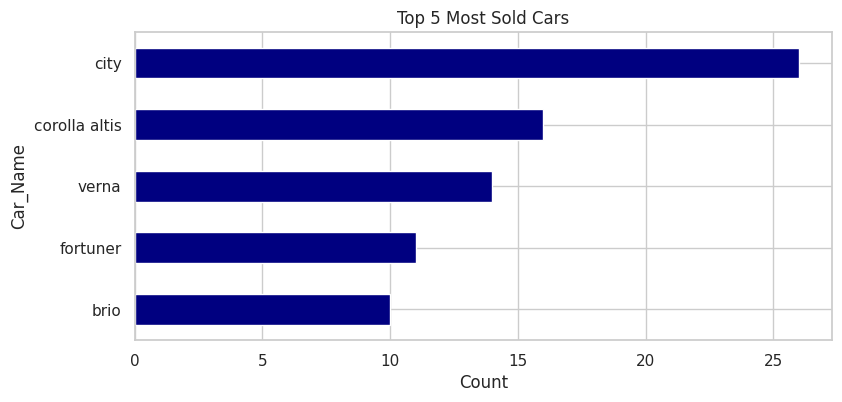

In [7]:
# Q22: Filter Cars
cars_df = df[df['Vehicle_Type'] == 'Car']

# Q23: Oldest Car
oldest_car = cars_df.loc[cars_df['Year'].idxmin()]

# Q24: Newest Car
newest_car = cars_df.loc[cars_df['Year'].idxmax()]

# Q25: Standout / Exceptional Car Deals
highest_priced_car = cars_df.loc[cars_df['Selling_Price'].idxmax()]
highest_retention_car = cars_df.sort_values(by='Retention_Pct', ascending=False).iloc[0]

print("="*60)
print("CARS ANALYSIS")
print("="*60)
print(f"Q22: Total Cars in Data          : {len(cars_df)}")
print(f"Q23: Oldest Car Sold             : {oldest_car['Car_Name']} ({oldest_car['Year']}) - ₹{oldest_car['Selling_Price']} Lakhs")
print(f"Q24: Newest Car Sold             : {newest_car['Car_Name']} ({newest_car['Year']}) - ₹{newest_car['Selling_Price']} Lakhs")
print(f"Q25: Highest Priced Car Deal     : {highest_priced_car['Car_Name']} ({highest_priced_car['Year']}) sold for ₹{highest_priced_car['Selling_Price']} Lakhs (Original: ₹{highest_priced_car['Present_Price']} Lakhs)")
print(f"     Highest Value Retention Car : {highest_retention_car['Car_Name']} ({highest_retention_car['Year']}) retained {highest_retention_car['Retention_Pct']:.2f}% of original price")
print("="*60)

# Visualizing Top 5 Cars
plt.figure(figsize=(9, 4))
cars_df['Car_Name'].value_counts().head(5).plot(kind='barh', color='navy')
plt.title('Top 5 Most Sold Cars')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()